# Imports

In [2]:
import os
import json
import random

import cv2
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import torch
import torch.nn as nn
import torch.nn.functional as F

from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import (
    SequentialLR,
    LinearLR,
    CosineAnnealingLR,
)
from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
)

from config import CFG

# initalize transformers

In [2]:
def get_transforms(cfg):
    """
    Gibt (train_transform, val_transform) zurück.
    img_size und Augmentierungs-Parameter kommen aus CFG.
    """

    train_transform = A.Compose([
        # ── Geometrisch ───────────────────────────────────────────
        A.RandomResizedCrop(size=(cfg.img_size, cfg.img_size), scale=(0.8, 1.0)),
        A.HorizontalFlip(p=cfg.aug_p_flip),
        A.VerticalFlip(p=cfg.aug_p_flip),
        A.Affine(
            translate_percent = (-0.1, 0.1),
            scale             = (0.9, 1.1),
            rotate            = (-180, 180),
            p                 = 0.7
        ),

        # ── Farbe & Helligkeit ────────────────────────────────────
        A.OneOf([
            A.RandomBrightnessContrast(p=1.0),
            A.RandomGamma(p=1.0),
            A.HueSaturationValue(p=1.0),
        ], p=cfg.aug_p_color),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.4),

        # ── Rauschen & Unschärfe (Gerätevariation) ────────────────
        A.GaussNoise(noise_scale_factor=0.1, p=0.3),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),

        # ── Dermoskopie-spezifisch ────────────────────────────────
        A.CoarseDropout(
            p          = cfg.aug_p_cutout,
            num_holes_range=(1, 3),
            hole_height_range=(0.1, 0.2),
            hole_width_range=(0.1, 0.2),
        ),

        # ── Normalisierung & Tensor ───────────────────────────────
        A.Normalize(
            mean = [0.485, 0.456, 0.406],   # ImageNet-Werte
            std  = [0.229, 0.224, 0.225],
        ),
        ToTensorV2(),
    ])

    val_transform = A.Compose([
        A.Resize(cfg.img_size, cfg.img_size),
        A.Normalize(
            mean = [0.485, 0.456, 0.406],
            std  = [0.229, 0.224, 0.225],
        ),
        ToTensorV2(),
    ])

    return train_transform, val_transform


def get_tta_transforms(cfg):
    """
    Test-Time Augmentation: Liste von Transforms für Inferenz.
    Jedes Bild wird cfg.tta_steps mal unterschiedlich augmentiert,
    die Predictions werden gemittelt.
    """
    tta_list = []

    for _ in range(cfg.tta_steps):
        tta_list.append(A.Compose([
            A.Resize(cfg.img_size, cfg.img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Affine(rotate=(-45, 45), p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.Normalize(
                mean = [0.485, 0.456, 0.406],
                std  = [0.229, 0.224, 0.225],
            ),
            ToTensorV2(),
        ]))

    return tta_list

# normalize data

In [3]:
def prepare_metadata(df: pd.DataFrame, img_dir: str = None) -> tuple[pd.DataFrame, list[str]]:
    df = df.copy()

    # ── Alter ─────────────────────────────────────────────────────
    median_age     = df['age_approx'].median()
    df['age_norm'] = df['age_approx'].fillna(median_age) / 90.0

    # ── Geschlecht ────────────────────────────────────────────────
    df['sex_enc']  = df['sex'].map({'male': 1, 'female': 0}).fillna(0.5)

    # ── Körperstelle ──────────────────────────────────────────────
    site_dummies = pd.get_dummies(
        df['anatom_site_general_challenge'],
        prefix='site', dummy_na=True
    )
    df = pd.concat([df, site_dummies], axis=1)

    # ── n_images: Anzahl Bilder pro Patient ───────────────────────
    # Patienten mit vielen Bildern haben oft Verlaufsdokumentation
    df['n_images'] = df['patient_id'].map(
        df.groupby('patient_id')['image_name'].count()
    ).fillna(1)
    df['n_images'] = np.log1p(df['n_images'].values)  # log-skalieren: 1→0, 10→2.3, 100→4.6

    # ── image_size: Dateigrösse des Bildes ────────────────────────
    # Grössere Dateien = mehr Details = potenziell komplexere Läsion
    if img_dir is not None:
        sizes = []
        for name in df['image_name']:
            path = os.path.join(img_dir, f"{name}{CFG.img_ext}")
            sizes.append(os.path.getsize(path) if os.path.exists(path) else 0)
        df['image_size'] = np.log1p(sizes)   # log-skalieren
    else:
        df['image_size'] = 0.0               # Test-Set ohne Pfad: Nullwert

    # ── Meta-Spalten zusammenstellen ──────────────────────────────
    meta_cols = (
        ['age_norm', 'sex_enc', 'n_images', 'image_size']
        + [c for c in df.columns if c.startswith('site_')]
    )

    df[meta_cols] = df[meta_cols].fillna(0).astype('float32')
    return df, meta_cols

# Melanoma Data set

In [4]:
class MelanomaDataset(Dataset):
    def __init__(
        self,
        df:        pd.DataFrame,
        img_dir:   str,
        meta_cols: list[str],
        transform=None,
        is_test:   bool = False,
        img_ext:   str  = '.png',
    ):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.meta_cols = meta_cols
        self.transform = transform
        self.is_test   = is_test
        self.img_ext   = img_ext

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        # Bild laden (OpenCV → RGB)
        img_path = os.path.join(self.img_dir, f"{row['image_name']}{self.img_ext}")
        image    = cv2.imread(img_path)

        if image is None:
            # Raising an error if an image file is not found or cannot be read.
            # This helps identify data integrity issues early.
            raise FileNotFoundError(f"Bild nicht gefunden oder konnte nicht gelesen werden: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Albumentations erwartet numpy HWC uint8
        if self.transform:
            image = self.transform(image=image)['image']

        # Metadaten als Float-Tensor
        meta = torch.tensor(
            self.df.loc[idx, self.meta_cols].values.astype('float32')
        )

        if self.is_test:
            return image, meta

        label = torch.tensor(row['target'], dtype=torch.float32)
        return image, meta, label


# get loaders

In [5]:
def make_splits(df, cfg):
    sgkf = StratifiedGroupKFold(
        n_splits=cfg.n_folds,
        shuffle=True,
        random_state=cfg.seed
    )

    return list(
        sgkf.split(
            df,
            y=df["target"],
            groups=df["patient_id"]
        )
    )

def get_loaders(
    df:         pd.DataFrame,
    fold:       int,
    meta_cols:  list[str],
    cfg,
    train_tfm,
    val_tfm,
    splits=None,          # ← NEU: vorberechnete Splits akzeptieren
) -> tuple[DataLoader, DataLoader]:
    if splits is None:
        splits = make_splits(df, cfg)

    train_idx, val_idx = splits[fold]

    df_train = df.iloc[train_idx]
    df_val   = df.iloc[val_idx]

    train_ds = MelanomaDataset(
        df        = df_train,
        img_dir   = cfg.img_dir,
        meta_cols = meta_cols,
        transform = train_tfm,
        img_ext   = cfg.img_ext,
    )
    val_ds = MelanomaDataset(
        df        = df_val,
        img_dir   = cfg.img_dir,
        meta_cols = meta_cols,
        transform = val_tfm,
        img_ext   = cfg.img_ext,
    )

    labels   = df_train['target'].values
    class_w  = 1.0 / np.bincount(labels).astype(float)
    sample_w = torch.tensor(class_w[labels], dtype=torch.float32)

    sampler = WeightedRandomSampler(
        weights     = sample_w,
        num_samples = len(sample_w),
        replacement = True
    )

    train_loader = DataLoader(
        train_ds,
        batch_size  = cfg.batch_size,
        sampler     = sampler,
        num_workers = cfg.num_workers,
        pin_memory  = True,           
        drop_last   = True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size  = cfg.batch_size * 2,
        shuffle     = False,
        num_workers = cfg.num_workers,
        pin_memory  = True,          
    )

    return train_loader, val_loader

# Loader for test data

In [6]:
def get_test_loader(
    df:        pd.DataFrame,
    meta_cols: list[str],
    cfg,
    test_tfm,
) -> DataLoader:
    """Loader für Kaggle-Submission (kein Label, kein Sampler)."""
    test_ds = MelanomaDataset(
        df        = df,
        img_dir   = cfg.test_img_dir,
        meta_cols = meta_cols,
        transform = test_tfm,
        is_test   = True,
        img_ext   = cfg.img_ext,
    )
    return DataLoader(
        test_ds,
        batch_size  = cfg.batch_size * 2,
        shuffle     = False,
        num_workers = cfg.num_workers
    )

# Sample Run

In [7]:
df = pd.read_csv(CFG.train_csv)
df, meta_cols = prepare_metadata(df, img_dir=CFG.img_dir)

train_tfm, val_tfm = get_transforms(CFG)
train_loader, val_loader = get_loaders(df, fold=0, meta_cols=meta_cols,
                                       cfg=CFG, train_tfm=train_tfm,
                                       val_tfm=val_tfm)
df_test = pd.read_csv(CFG.test_csv)
df_test, _ = prepare_metadata(df_test, img_dir=CFG.test_img_dir)  # Meta-Cols müssen auch für Test-Set vorbereitet werden
test_loader = get_test_loader(df_test, meta_cols=meta_cols, cfg=CFG,
                              test_tfm=val_tfm)  # Test-Set bekommt gleiche Transforms wie Val

images, meta, labels = next(iter(train_loader))
print(f"images : {images.shape}")    # [32, 3, 384, 384]
print(f"meta   : {meta.shape}")      # [32, ~10]
print(f"labels : {labels.mean():.3f}")  # ~0.5 → Sampler funktioniert
print(f"n_meta : {len(meta_cols)}")
print(f"Fold 0 — Train: {len(train_loader.dataset):,} | Val: {len(val_loader.dataset):,}")
print(f"Test-Loader: {len(test_loader.dataset):,} Bilder")
print(f"Meta-Features ({len(meta_cols)}): {meta_cols}")

images : torch.Size([32, 3, 384, 384])
meta   : torch.Size([32, 11])
labels : 0.562
n_meta : 11
Fold 0 — Train: 26,499 | Val: 6,627
Test-Loader: 10,982 Bilder
Meta-Features (11): ['age_norm', 'sex_enc', 'n_images', 'image_size', 'site_head/neck', 'site_lower extremity', 'site_oral/genital', 'site_palms/soles', 'site_torso', 'site_upper extremity', 'site_nan']


In [8]:
df_test['image_name'][0]

'ISIC_0052060'

# Example Picture

In [9]:
def visualise_augmentation(image_id: str, cfg=CFG, transform=train_tfm):
    """
    Given an image ID (e.g. 'ISIC_0015719'), shows the original
    and augmented version side by side.
    """
    img_path = os.path.join(cfg.img_dir, f"{image_id}{cfg.img_ext}")
    image = cv2.imread(img_path)
    if image is None:
        raise FileNotFoundError(f"Image not found: {img_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Strip Normalize and ToTensorV2 so output stays as uint8 numpy [H,W,C]
    display_tfm = A.Compose([
        t for t in transform.transforms
        if not isinstance(t, (A.Normalize, ToTensorV2))
    ])

    augmented = display_tfm(image=image)['image']

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f"Image ID: {image_id}", fontsize=13, fontweight='bold')

    axes[0].imshow(image)
    axes[0].set_title('Original', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(augmented)
    axes[1].set_title('Augmented', fontsize=11)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

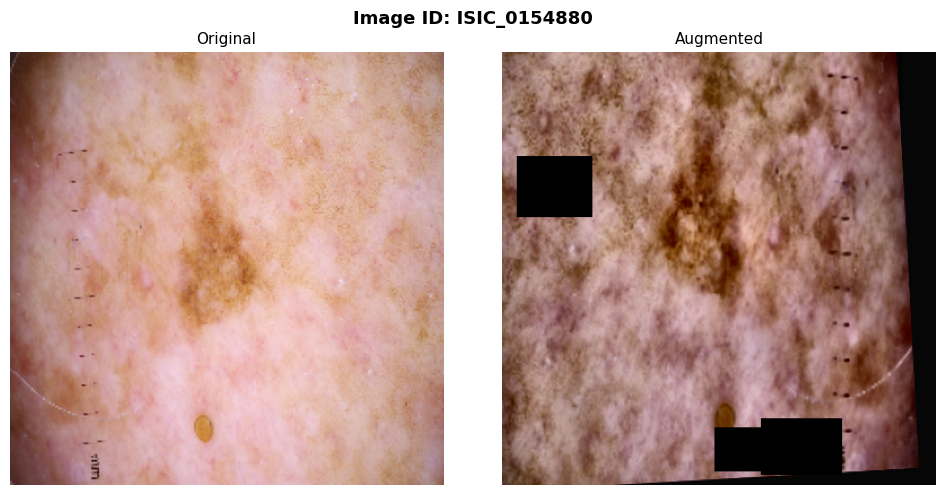

In [10]:
visualise_augmentation(df['image_name'][110])

# Melanoma Model

In [11]:
class GeM(nn.Module):
    """
    Generalized Mean Pooling — bessere Feature-Aggregation als AvgPool.
    p=1 = AvgPool, p→∞ = MaxPool, p=3 = optimaler Sweetspot für Texturen.
    p wird mittrainiert.
    """
    def __init__(self, p: float = 3.0, eps: float = 1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W) → (B, C)
        return F.adaptive_avg_pool2d(
            x.clamp(min=self.eps).pow(self.p),
            output_size=1
        ).pow(1.0 / self.p).squeeze(-1).squeeze(-1)


class MelanomaModel(nn.Module):
    def __init__(self, n_meta_features: int, cfg):
        super().__init__()

        # ── Bild-Branch: EfficientNet + GeM ───────────────────────
        self.backbone = timm.create_model(
            cfg.backbone,
            pretrained  = cfg.pretrained,
            num_classes = 0,
            global_pool = ''        # ← leer lassen: wir machen Pooling selbst
        )
        img_feat_dim = self.backbone.num_features  # 1792 für B4

        self.gem_pool = GeM(p=3.0)  # ← ersetzt global_pool='avg'

        # ── Metadaten-Branch: SiLU statt ReLU ─────────────────────
        self.meta_branch = nn.Sequential(
            nn.Linear(n_meta_features, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),              # ← Swish/SiLU statt ReLU
            nn.Dropout(p=0.3),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),              # ← Swish/SiLU statt ReLU
        )

        # ── Fusion Head: SiLU statt ReLU ──────────────────────────
        fused_dim = img_feat_dim + 256
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),              # ← Swish/SiLU statt ReLU
            nn.Dropout(p=cfg.dropout),
            nn.Linear(512, 1)
        )

    def forward(self, image: torch.Tensor, meta: torch.Tensor) -> torch.Tensor:
        feat  = self.backbone.forward_features(image)  # (B, C, H, W)
        feat  = self.gem_pool(feat)                    # (B, C) via GeM
        meta  = self.meta_branch(meta)                 # (B, 256)
        fused = torch.cat([feat, meta], dim=1)         # (B, C+256)
        return self.classifier(fused).squeeze(1)       # (B,)

In [12]:
# Schnellcheck
n_meta = len(meta_cols)
model  = MelanomaModel(n_meta_features=n_meta, cfg=CFG).to(CFG.device)
print(f"Backbone features : {model.backbone.num_features}")
print(f"Meta features     : {n_meta}")
print(f"Device            : {CFG.device}")

# Dummy Forward Pass
with torch.no_grad():
    dummy_img  = torch.randn(2, 3, CFG.img_size, CFG.img_size).to(CFG.device)
    dummy_meta = torch.randn(2, n_meta).to(CFG.device)
    out = model(dummy_img, dummy_meta)
    print(f"Output shape      : {out.shape}")   # torch.Size([2])
    print("Forward pass OK")

Backbone features : 2048
Meta features     : 11
Device            : cuda
Output shape      : torch.Size([2])
Forward pass OK


# Helper Functions

In [13]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

def focal_loss(logits, targets, alpha=0.25, gamma=2.0, smoothing=0.0):
    logits = torch.clamp(logits, min=-50, max=50)   # ← NEU
    targets = targets.float()
    if smoothing > 0:
        targets = targets * (1 - smoothing) + 0.5 * smoothing

    bce = nn.functional.binary_cross_entropy_with_logits(
        logits, targets, reduction="none"
    )

    probs = torch.sigmoid(logits)
    pt = probs * targets + (1 - probs) * (1 - targets)

    alpha_t = alpha * targets + (1 - alpha) * (1 - targets)

    loss = alpha_t * (1 - pt) ** gamma * bce
    return loss.mean()

def get_optimizer(model, cfg):
    """
    Optimizer für run_kfold.
    Ablation-Ergebnis: Uniform LR (AUC 0.8793) > Discriminative LR (AUC 0.8387).
    Steuerung über cfg.uniform_lr Flag.
    """
    if getattr(cfg, 'uniform_lr', False):
        # Uniform LR: alle Parameter gleiche Lernrate
        return torch.optim.AdamW(
            model.parameters(),
            lr=cfg.lr,
            weight_decay=cfg.weight_decay
        )
    else:
        # Discriminative LR: Backbone bekommt kleinere LR
        return torch.optim.AdamW([
            {'params': model.backbone.parameters(),   'lr': cfg.lr * cfg.backbone_lr_factor},
            {'params': model.gem_pool.parameters(),   'lr': cfg.lr * cfg.backbone_lr_factor},
            {'params': model.meta_branch.parameters(), 'lr': cfg.lr},
            {'params': model.classifier.parameters(),  'lr': cfg.lr},
        ], weight_decay=cfg.weight_decay)

def get_scheduler(optimizer, cfg):
    # Phase 1: Warmup — LR steigt linear von 10% auf 100% über warmup_epochs
    warmup = LinearLR(
        optimizer,
        start_factor = 0.1,          # startet bei lr * 0.1
        end_factor   = 1.0,
        total_iters  = cfg.warmup_epochs
    )
    # Phase 2: Cosine Decay — LR sinkt von 100% auf eta_min
    cosine = CosineAnnealingLR(
        optimizer,
        T_max   = cfg.epochs - cfg.warmup_epochs,
        eta_min = 1e-6
    )
    # Beide kombinieren: erst Warmup, dann Cosine
    return SequentialLR(
        optimizer,
        schedulers = [warmup, cosine],
        milestones = [cfg.warmup_epochs]
    )

def evaluate_oof(
    oof_labels,
    oof_preds,
    output_dir,
    threshold=0.5,
    filename="oof_metrics.json"
):
    os.makedirs(output_dir, exist_ok=True)

    oof_labels = np.asarray(oof_labels).astype(int)
    oof_preds = np.asarray(oof_preds).astype(float)

    y_pred = (oof_preds >= threshold).astype(int)

    roc_auc = roc_auc_score(oof_labels, oof_preds)
    pr_auc = average_precision_score(oof_labels, oof_preds)

    cm = confusion_matrix(oof_labels, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)

    metrics = {
        "threshold": float(threshold),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "accuracy": float(accuracy_score(oof_labels, y_pred)),
        "precision": float(precision_score(oof_labels, y_pred, zero_division=0)),
        "recall": float(recall_score(oof_labels, y_pred, zero_division=0)),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "f1": float(f1_score(oof_labels, y_pred, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

    metrics_path = os.path.join(output_dir, filename)

    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=4)

    print("\nOOF Evaluation")
    print("--------------------")
    print(f"ROC-AUC      : {metrics['roc_auc']:.4f}")
    print(f"PR-AUC       : {metrics['pr_auc']:.4f}")
    print(f"Accuracy     : {metrics['accuracy']:.4f}")
    print(f"Precision    : {metrics['precision']:.4f}")
    print(f"Recall/Sens. : {metrics['recall']:.4f}")
    print(f"Specificity  : {metrics['specificity']:.4f}")
    print(f"F1           : {metrics['f1']:.4f}")
    print(f"TP / FP / FN / TN: {tp} / {fp} / {fn} / {tn}")
    print(f"Saved metrics to: {metrics_path}")

def mixup_batch(images, labels, alpha=0.4):
    """Apply mixup to a batch. Returns mixed images and two label sets + lambda."""
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1 - lam) * images[idx]
    return mixed, labels, labels[idx], lam

def mixup_loss(logits, labels_a, labels_b, lam, cfg):
    loss_a = focal_loss(logits, labels_a, cfg.focal_alpha, cfg.focal_gamma, cfg.label_smoothing)
    loss_b = focal_loss(logits, labels_b, cfg.focal_alpha, cfg.focal_gamma, cfg.label_smoothing)
    return lam * loss_a + (1 - lam) * loss_b

seed_everything(CFG.seed)
print("Hilfsfunktionen bereit")

Hilfsfunktionen bereit


# Ablation testing

In [12]:
class MelanomaModelAblation(nn.Module):
    """
    Identische Architektur wie MelanomaModel (GeM + SiLU)
    aber mit use_meta Flag für Ablation Studies.
    """
    def __init__(self, n_meta_features: int, cfg, use_meta: bool = True):
        super().__init__()
        self.use_meta = use_meta

        # ── Backbone + GeM ────────────────────────────────────────
        self.backbone = timm.create_model(
            cfg.backbone,
            pretrained  = cfg.pretrained,
            num_classes = 0,
            global_pool = ''        # ← GeM übernimmt Pooling
        )
        img_feat_dim  = self.backbone.num_features
        self.gem_pool = GeM(p=3.0)  # ← gleich wie MelanomaModel

        # ── Meta-Branch (optional) ────────────────────────────────
        if use_meta and n_meta_features > 0:
            self.meta_branch = nn.Sequential(
                nn.Linear(n_meta_features, 256),
                nn.BatchNorm1d(256),
                nn.SiLU(),          # ← SiLU statt ReLU
                nn.Dropout(0.3),
                nn.Linear(256, 256),
                nn.BatchNorm1d(256),
                nn.SiLU(),          # ← SiLU statt ReLU
            )
            fused_dim = img_feat_dim + 256
        else:
            self.meta_branch = None
            fused_dim = img_feat_dim

        # ── Fusion Head ───────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),              # ← SiLU statt ReLU
            nn.Dropout(cfg.dropout),
            nn.Linear(512, 1)
        )

    def forward(self, image, meta=None):
        feat  = self.backbone.forward_features(image)   # (B, C, H, W)
        feat  = self.gem_pool(feat)                      # (B, C)
        if self.use_meta and meta is not None and self.meta_branch is not None:
            fused = torch.cat([feat, self.meta_branch(meta)], dim=1)
        else:
            fused = feat
        return self.classifier(fused).squeeze(1)

## Ablation run

In [15]:
# ── Ablation Study ────────────────────────────────────────────────────────────

ABLATION_EPOCHS = 8
ABLATION_FOLD   = 0

from sklearn.metrics import precision_recall_curve

def find_best_threshold(labels, preds):
    precisions, recalls, thresholds = precision_recall_curve(labels, preds)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    best_idx   = np.argmax(f1_scores)
    return thresholds[best_idx]

def get_scheduler_ablation(optimizer, cfg, epochs):
    warmup = LinearLR(optimizer, start_factor=0.1,
                      end_factor=1.0, total_iters=cfg.warmup_epochs)
    cosine = CosineAnnealingLR(optimizer,
                                T_max=epochs - cfg.warmup_epochs,
                                eta_min=1e-6)
    return SequentialLR(optimizer, schedulers=[warmup, cosine],
                        milestones=[cfg.warmup_epochs])

def get_current_lrs(optimizer):
    """
    Returns current learning rates for all optimizer parameter groups.
    """
    return [group["lr"] for group in optimizer.param_groups]


def get_optimizer_ablation(model, cfg, uniform_lr=False):
    """
    Eigener Optimizer für Ablation.
    Behandelt auch den Fall, dass meta_branch None ist.
    """

    if uniform_lr:
        return torch.optim.AdamW(
            model.parameters(),
            lr=cfg.lr,
            weight_decay=cfg.weight_decay
        )

    param_groups = [
        {
            "params": model.backbone.parameters(),
            "lr": cfg.lr * cfg.backbone_lr_factor,
            "name": "backbone"
        },
        {
            "params": model.gem_pool.parameters(),
            "lr": cfg.lr * cfg.backbone_lr_factor,
            "name": "gem_pool"
        },
        {
            "params": model.classifier.parameters(),
            "lr": cfg.lr,
            "name": "classifier"
        },
    ]

    if model.meta_branch is not None:
        param_groups.append({
            "params": model.meta_branch.parameters(),
            "lr": cfg.lr,
            "name": "meta_branch"
        })

    return torch.optim.AdamW(
        param_groups,
        weight_decay=cfg.weight_decay
    )


def compute_binary_metrics(labels, preds, threshold=None):
    labels = np.asarray(labels).astype(int)
    preds  = np.asarray(preds).astype(float)

    # Threshold automatisch optimieren wenn nicht angegeben
    if threshold is None:
        threshold = find_best_threshold(labels, preds)

    y_pred = (preds >= threshold).astype(int)

    auc     = roc_auc_score(labels, preds)
    pr_auc  = average_precision_score(labels, preds)
    tn, fp, fn, tp = confusion_matrix(labels, y_pred).ravel()

    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    precision   = precision_score(labels, y_pred, zero_division=0)
    recall      = recall_score(labels, y_pred, zero_division=0)
    f1          = f1_score(labels, y_pred, zero_division=0)
    accuracy    = accuracy_score(labels, y_pred)

    return {
        "auc":         float(auc),
        "pr_auc":      float(pr_auc),
        "threshold":   round(float(threshold), 4),
        "accuracy":    float(accuracy),
        "precision":   float(precision),
        "recall":      float(recall),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "f1":          float(f1),
        "tp": int(tp), "fp": int(fp),
        "fn": int(fn), "tn": int(tn),
    }


def compute_loss_from_name(logits, labels, cfg, loss_fn):
    """
    Selects loss function for ablation experiments.
    """

    if loss_fn == "focal":
        loss = focal_loss(
            logits,
            labels,
            alpha=cfg.focal_alpha,
            gamma=cfg.focal_gamma,
            smoothing=cfg.label_smoothing
        )

    elif loss_fn == "bce":
        loss = nn.functional.binary_cross_entropy_with_logits(
            logits,
            labels.float()
        )

    elif loss_fn == "bce_weighted":
        pos_weight = torch.tensor([50.0], device=cfg.device)
        loss = nn.functional.binary_cross_entropy_with_logits(
            logits,
            labels.float(),
            pos_weight=pos_weight
        )

    else:
        raise ValueError(f"Unknown loss_fn: {loss_fn}")

    return loss


def make_safe_experiment_name(exp_name):
    """
    Converts experiment name into safe folder name.
    """

    return (
        exp_name
        .lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("(", "")
        .replace(")", "")
        .replace(".", "")
        .replace("/", "_")
        .replace("ä", "ae")
        .replace("ö", "oe")
        .replace("ü", "ue")
    )


def run_single_experiment(
    exp_name,
    train_loader,
    val_loader,
    n_meta,
    cfg,
    use_meta=True,
    loss_fn="focal",
    uniform_lr=False,
):
    """
    Runs one ablation experiment on one fold.
    Saves:
    - epoch_logs.csv
    - best_val_predictions.csv
    """

    seed_everything(cfg.seed)

    safe_exp_name = make_safe_experiment_name(exp_name)
    exp_dir = os.path.join(cfg.output_dir, "ablations", safe_exp_name)
    os.makedirs(exp_dir, exist_ok=True)

    device_type = "cuda" if str(cfg.device).startswith("cuda") else "cpu"

    print("\n" + "-" * 60)
    print(f"Experiment : {exp_name}")
    print(f"Use meta   : {use_meta}")
    print(f"Loss       : {loss_fn}")
    print(f"Uniform LR : {uniform_lr}")
    print(f"Output dir : {exp_dir}")
    print("-" * 60)

    model = MelanomaModelAblation(
        n_meta_features=n_meta if use_meta else 0,
        cfg=cfg,
        use_meta=use_meta
    ).to(cfg.device)

    optimizer = get_optimizer_ablation(
        model,
        cfg,
        uniform_lr=uniform_lr
    )

    scheduler = get_scheduler_ablation(optimizer, cfg, ABLATION_EPOCHS)  # statt get_scheduler

    scaler = GradScaler(
        "cuda",
        enabled=cfg.use_amp
    )

    best_auc = -np.inf
    best_epoch = None
    best_preds = None
    best_labels = None
    best_metrics = None

    epoch_logs = []

    for epoch in range(ABLATION_EPOCHS):
        print(f"\nEpoch {epoch + 1}/{ABLATION_EPOCHS}")

        # ── Train ─────────────────────────────────────────────────
        model.train()

        train_loss_total = 0.0
        train_labels = []
        train_preds = []

        optimizer.zero_grad(set_to_none=True)

        for step, (images, meta, labels) in enumerate(train_loader):
            images = images.to(cfg.device, non_blocking=True)
            labels = labels.to(cfg.device, non_blocking=True)

            if use_meta:
                meta = meta.to(cfg.device, non_blocking=True)
            else:
                meta = None

            with autocast(device_type=device_type, enabled=cfg.use_amp):
                logits = model(images, meta)
                loss = compute_loss_from_name(
                    logits=logits,
                    labels=labels,
                    cfg=cfg,
                    loss_fn=loss_fn
                )

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

            train_loss_total += loss.item()

            train_labels.extend(
                labels.detach().cpu().numpy().reshape(-1)
            )

            train_preds.extend(
                torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
            )

            if (step + 1) % cfg.log_interval == 0:
                print(
                    f"  Step {step + 1}/{len(train_loader)} "
                    f"| Loss: {loss.item():.4f} "
                    f"| GradNorm: {float(grad_norm):.4f}"
                )

        scheduler.step()

        train_loss = train_loss_total / len(train_loader)

        train_metrics = compute_binary_metrics(
            labels=train_labels,
            preds=train_preds
        )

        # ── Validate ──────────────────────────────────────────────
        model.eval()

        val_loss_total = 0.0
        val_labels = []
        val_preds = []

        with torch.no_grad():
            for images, meta, labels in val_loader:
                images = images.to(cfg.device, non_blocking=True)
                labels = labels.to(cfg.device, non_blocking=True)

                if use_meta:
                    meta = meta.to(cfg.device, non_blocking=True)
                else:
                    meta = None

                with autocast(device_type=device_type, enabled=cfg.use_amp):
                    logits = model(images, meta)
                    val_loss = compute_loss_from_name(
                        logits=logits,
                        labels=labels,
                        cfg=cfg,
                        loss_fn=loss_fn
                    )

                val_loss_total += val_loss.item()

                val_labels.extend(
                    labels.detach().cpu().numpy().reshape(-1)
                )

                val_preds.extend(
                    torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
                )

        val_loss = val_loss_total / len(val_loader)

        val_metrics = compute_binary_metrics(
            labels=val_labels,
            preds=val_preds
        )

        current_lrs = get_current_lrs(optimizer)

        epoch_log = {
            "experiment": exp_name,
            "epoch": epoch + 1,

            "train_loss": float(train_loss),
            "train_auc": train_metrics["auc"],
            "train_pr_auc": train_metrics["pr_auc"],
            "train_accuracy": train_metrics["accuracy"],
            "train_sensitivity": train_metrics["sensitivity"],
            "train_specificity": train_metrics["specificity"],
            "train_f1": train_metrics["f1"],

            "val_loss": float(val_loss),
            "val_auc": val_metrics["auc"],
            "val_pr_auc": val_metrics["pr_auc"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_sensitivity": val_metrics["sensitivity"],
            "val_specificity": val_metrics["specificity"],
            "val_f1": val_metrics["f1"],
            "val_tp": val_metrics["tp"],
            "val_fp": val_metrics["fp"],
            "val_fn": val_metrics["fn"],
            "val_tn": val_metrics["tn"],

            "lr_group_0": float(current_lrs[0]),
            "lr_group_last": float(current_lrs[-1]),
        }

        epoch_logs.append(epoch_log)

        print(
            f"  [{exp_name}] "
            f"Epoch {epoch + 1}/{ABLATION_EPOCHS} "
            f"| Train Loss: {train_loss:.4f} "
            f"| Train AUC: {train_metrics['auc']:.4f} "
            f"| Val Loss: {val_loss:.4f} "
            f"| Val AUC: {val_metrics['auc']:.4f} "
            f"| Val PR-AUC: {val_metrics['pr_auc']:.4f} "
            f"| Sens: {val_metrics['sensitivity']:.4f} "
            f"| Spec: {val_metrics['specificity']:.4f} "
            f"| F1: {val_metrics['f1']:.4f}"
        )

        if val_metrics["auc"] > best_auc:
            best_auc = val_metrics["auc"]
            best_epoch = epoch + 1
            best_preds = np.asarray(val_preds)
            best_labels = np.asarray(val_labels)
            best_metrics = val_metrics

            print(
                f"  ✓ New best epoch: {best_epoch} "
                f"| AUC: {best_auc:.4f} "
                f"| PR-AUC: {best_metrics['pr_auc']:.4f}"
            )

    # ── Save epoch logs ───────────────────────────────────────────
    epoch_logs_df = pd.DataFrame(epoch_logs)
    epoch_log_path = os.path.join(exp_dir, "epoch_logs.csv")
    epoch_logs_df.to_csv(epoch_log_path, index=False)

    # ── Save best validation predictions ─────────────────────────
    best_pred_df = pd.DataFrame({
        "target": best_labels.astype(int),
        "pred": best_preds.astype(float),
    })

    best_pred_path = os.path.join(exp_dir, "best_val_predictions.csv")
    best_pred_df.to_csv(best_pred_path, index=False)

    result = {
        "experiment": exp_name,
        "best_epoch": int(best_epoch),
        "best_auc": round(float(best_auc), 4),
        "best_pr_auc": round(float(best_metrics["pr_auc"]), 4),
        "threshold":   round(float(best_metrics["threshold"]), 4), 
        "accuracy": round(float(best_metrics["accuracy"]), 4),
        "sensitivity": round(float(best_metrics["sensitivity"]), 4),
        "specificity": round(float(best_metrics["specificity"]), 4),
        "precision": round(float(best_metrics["precision"]), 4),
        "recall": round(float(best_metrics["recall"]), 4),
        "f1": round(float(best_metrics["f1"]), 4),
        "tp": int(best_metrics["tp"]),
        "fp": int(best_metrics["fp"]),
        "fn": int(best_metrics["fn"]),
        "tn": int(best_metrics["tn"]),
        "epoch_log_path": epoch_log_path,
        "best_pred_path": best_pred_path,
    }

    print("\nBest result:")
    print(
        f"  AUC: {result['best_auc']:.4f} "
        f"| PR-AUC: {result['best_pr_auc']:.4f} "
        f"| Sens: {result['sensitivity']:.4f} "
        f"| Spec: {result['specificity']:.4f} "
        f"| F1: {result['f1']:.4f}"
    )

    print(f"  Epoch log saved to: {epoch_log_path}")
    print(f"  Best predictions saved to: {best_pred_path}")

    # ── Cleanup ───────────────────────────────────────────────────
    del model, optimizer, scheduler, scaler

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


def run_ablation_study(df, meta_cols, cfg):
    """
    Runs all ablation experiments on one selected fold.
    """

    print("Daten vorbereiten...")

    train_tfm, val_tfm = get_transforms(cfg)

    train_loader, val_loader = get_loaders(
        df=df,
        fold=ABLATION_FOLD,
        meta_cols=meta_cols,
        cfg=cfg,
        train_tfm=train_tfm,
        val_tfm=val_tfm
    )

    # Loader ohne WeightedSampler für separate Ablation
    splits = make_splits(df, cfg)
    train_idx, val_idx = splits[ABLATION_FOLD]

    df_train = df.iloc[train_idx].reset_index(drop=True)

    train_ds_no_sampler = MelanomaDataset(
        df=df_train,
        img_dir=cfg.img_dir,
        meta_cols=meta_cols,
        transform=train_tfm,
        img_ext=cfg.img_ext
    )
    generator = torch.Generator()
    generator.manual_seed(cfg.seed) 

    train_loader_no_sampler = DataLoader(
        train_ds_no_sampler,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=True,
        drop_last=True,
        generator = generator
    )

    n_meta = len(meta_cols)
    results = []

    experiments = [
        (
            "Nur Bild Baseline",
            dict(
                use_meta=False,
                loss_fn="focal",
                uniform_lr=False
            )
        ),
        (
            "Bild plus Metadaten voll",
            dict(
                use_meta=True,
                loss_fn="focal",
                uniform_lr=False
            )
        ),
        (
            "BCE plus pos_weight",
            dict(
                use_meta=True,
                loss_fn="bce_weighted",
                uniform_lr=False
            )
        ),
        (
            "Uniform LR kein Disc",
            dict(
                use_meta=True,
                loss_fn="focal",
                uniform_lr=True
            )
        ),
    ]

    for name, kwargs in experiments:
        print(f"\n{'=' * 60}")
        print(f"  EXP: {name}")
        print(f"{'=' * 60}")

        result = run_single_experiment(
            exp_name=name,
            train_loader=train_loader,
            val_loader=val_loader,
            n_meta=n_meta,
            cfg=cfg,
            **kwargs
        )

        results.append(result)

    # Experiment ohne WeightedSampler
    print(f"\n{'=' * 60}")
    print("  EXP: Kein WeightedSampler")
    print(f"{'=' * 60}")

    result = run_single_experiment(
        exp_name="Kein WeightedSampler",
        train_loader=train_loader_no_sampler,
        val_loader=val_loader,
        n_meta=n_meta,
        cfg=cfg,
        use_meta=True,
        loss_fn="focal",
        uniform_lr=False
    )

    results.append(result)

    # ── Ergebnisse ────────────────────────────────────────────────
    results_df = pd.DataFrame(results).sort_values(
        "best_auc",
        ascending=False
    )

    print(f"\n{'=' * 60}")
    print(f"ABLATION ERGEBNISSE Fold {ABLATION_FOLD}, {ABLATION_EPOCHS} Epochs")
    print(f"{'=' * 60}")

    display_cols = [
        "experiment",
        "best_epoch",
        "best_auc",
        "best_pr_auc",
        "threshold", 
        "sensitivity",
        "specificity",
        "precision",
        "f1",
        "tp",
        "fp",
        "fn",
        "tn",
    ]

    print(results_df[display_cols].to_string(index=False))

    os.makedirs(cfg.output_dir, exist_ok=True)

    csv_path = os.path.join(cfg.output_dir, "ablation_results.csv")
    json_path = os.path.join(cfg.output_dir, "ablation_results.json")

    results_df.to_csv(csv_path, index=False)

    with open(json_path, "w") as f:
        json.dump(results, f, indent=4)

    print(f"\nGespeichert:")
    print(f"  CSV : {csv_path}")
    print(f"  JSON: {json_path}")

    return results_df


# ── Ablation starten ─────────────────────────────────────────────────────────
ablation_df = run_ablation_study(
    df=df,
    meta_cols=meta_cols,
    cfg=CFG
)

ablation_df

Daten vorbereiten...

  EXP: Nur Bild Baseline

------------------------------------------------------------
Experiment : Nur Bild Baseline
Use meta   : False
Loss       : focal
Uniform LR : False
Output dir : /teamspace/studios/this_studio/outputs/ablations/nur_bild_baseline
------------------------------------------------------------



Epoch 1/8
  Step 50/414 | Loss: 0.0923 | GradNorm: 0.8718
  Step 100/414 | Loss: 0.0864 | GradNorm: 0.7952
  Step 150/414 | Loss: 0.0753 | GradNorm: 0.6721
  Step 200/414 | Loss: 0.0667 | GradNorm: 0.5796
  Step 250/414 | Loss: 0.0559 | GradNorm: 0.5557
  Step 300/414 | Loss: 0.0604 | GradNorm: 0.5471
  Step 350/414 | Loss: 0.0712 | GradNorm: 0.5858
  Step 400/414 | Loss: 0.0621 | GradNorm: 0.5588
  [Nur Bild Baseline] Epoch 1/8 | Train Loss: 0.0759 | Train AUC: 0.6766 | Val Loss: 0.0568 | Val AUC: 0.7285 | Val PR-AUC: 0.0432 | Sens: 0.2479 | Spec: 0.9296 | F1: 0.0960
  ✓ New best epoch: 1 | AUC: 0.7285 | PR-AUC: 0.0432

Epoch 2/8
  Step 50/414 | Loss: 0.0730 | GradNorm: 0.6640
  Step 100/414 | Loss: 0.0503 | GradNorm: 0.4634
  Step 150/414 | Loss: 0.0800 | GradNorm: 0.6912
  Step 200/414 | Loss: 0.0579 | GradNorm: 0.4439
  Step 250/414 | Loss: 0.0507 | GradNorm: 0.4894
  Step 300/414 | Loss: 0.0696 | GradNorm: 0.5429
  Step 350/414 | Loss: 0.0529 | GradNorm: 0.4388
  Step 400/414 | L

,experiment,best_epoch,best_auc,best_pr_auc,threshold,accuracy,sensitivity,specificity,precision,recall,f1,tp,fp,fn,tn,epoch_log_path,best_pred_path
3,Uniform LR kein Disc,6,0.8793,0.1517,0.5,0.9502,0.4274,0.9596,0.1597,0.4274,0.2326,50,263,67,6247,/teamspace/studios/this_studio/outputs/ablatio...,/teamspace/studios/this_studio/outputs/ablatio...
2,BCE plus pos_weight,8,0.8432,0.0953,0.5,0.5135,0.9487,0.5057,0.0333,0.9487,0.0644,111,3218,6,3292,/teamspace/studios/this_studio/outputs/ablatio...,/teamspace/studios/this_studio/outputs/ablatio...
0,Nur Bild Baseline,8,0.8407,0.1001,0.5,0.8966,0.4957,0.9038,0.0848,0.4957,0.1448,58,626,59,5884,/teamspace/studios/this_studio/outputs/ablatio...,/teamspace/studios/this_studio/outputs/ablatio...
1,Bild plus Metadaten voll,7,0.8387,0.1183,0.5,0.8956,0.4786,0.9031,0.0815,0.4786,0.1393,56,631,61,5879,/teamspace/studios/this_studio/outputs/ablatio...,/teamspace/studios/this_studio/outputs/ablatio...
4,Kein WeightedSampler,8,0.7968,0.0869,0.5,0.9823,0.0000,1.0000,0.0000,0.0000,0.0000,0,0,117,6510,/teamspace/studios/this_studio/outputs/ablatio...,/teamspace/studios/this_studio/outputs/ablatio...


# Training Loop

In [19]:
def train_one_epoch(model, loader, optimizer, scaler, cfg):
    model.train()
    total_loss = 0
    all_labels, all_preds = [], []
    nan_steps = 0

    device_type = "cuda" if str(cfg.device).startswith("cuda") else "cpu"

    for images, meta, labels in loader:
        images = images.to(cfg.device, non_blocking=True)
        meta   = meta.to(cfg.device, non_blocking=True)
        labels = labels.to(cfg.device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # ── Mixup (50% der Batches) ───────────────────────────────
        use_mixup = np.random.random() < 0.5
        if use_mixup:
            lam = float(np.random.beta(0.4, 0.4))
            lam = np.clip(lam, 0.1, 0.9)   # ← NEU: verhindert extreme lam-Werte
            idx = torch.randperm(images.size(0), device=images.device)
            images_mixed = lam * images + (1 - lam) * images[idx]
            labels_b     = labels[idx]
        else:
            images_mixed = images

        with autocast(device_type=device_type, enabled=cfg.use_amp):
            logits = model(images_mixed, meta)

            if use_mixup:
                loss = (
                    lam       * focal_loss(logits, labels,   cfg.focal_alpha, cfg.focal_gamma, cfg.label_smoothing) +
                    (1 - lam) * focal_loss(logits, labels_b, cfg.focal_alpha, cfg.focal_gamma, cfg.label_smoothing)
                )
            else:
                loss = focal_loss(logits, labels, cfg.focal_alpha, cfg.focal_gamma, cfg.label_smoothing)

        # ── NaN guard ────────────────────────────────────────────
        if not torch.isfinite(loss):
            nan_steps += 1
            optimizer.zero_grad(set_to_none=True)
            scaler.update()             # AMP-Scaler trotzdem updaten
            print(f"  ⚠ NaN/Inf loss skipped (total skipped: {nan_steps})")
            continue                    # ← step überspringen, nicht akkumulieren

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(torch.sigmoid(logits).detach().cpu().numpy())

    if len(all_labels) == 0:
        raise RuntimeError("All steps produced NaN loss — check focal_loss implementation.")

    auc = roc_auc_score(all_labels, all_preds)
    return total_loss / len(loader), auc


@torch.no_grad()
def validate(model, loader, cfg):
    model.eval()
    total_loss = 0
    all_labels, all_preds = [], []

    device_type = "cuda" if str(cfg.device).startswith("cuda") else "cpu"  # ← FIX

    for images, meta, labels in loader:
        images = images.to(cfg.device, non_blocking=True)
        meta   = meta.to(cfg.device, non_blocking=True)
        labels = labels.to(cfg.device, non_blocking=True)

        with autocast(device_type=device_type, enabled=cfg.use_amp):  # ← FIX
            logits = model(images, meta)
            loss   = focal_loss(
                logits, labels,
                alpha     = cfg.focal_alpha,
                gamma     = cfg.focal_gamma,
                smoothing = cfg.label_smoothing,
            )

        total_loss += loss.item()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(torch.sigmoid(logits).cpu().numpy())

    preds = np.array(all_preds)
    auc   = roc_auc_score(all_labels, preds)
    return total_loss / len(loader), auc, preds

In [20]:
# ── 5b. Patch: add epoch logging to run_kfold ─────────────────────────────────
# Minimal diff from your existing run_kfold. Search for "# ← LOG" to see changes.

def run_kfold(df, meta_cols, cfg, early_stopping_patience=4):
    seed_everything(cfg.seed)
    os.makedirs(cfg.output_dir, exist_ok=True)

    fold_scores  = []
    fold_metrics = []
    epoch_logs   = []                                                    # ← LOG

    train_tfm, val_tfm = get_transforms(cfg)

    oof_preds  = np.zeros(len(df), dtype=np.float32)
    oof_labels = df["target"].values.astype(int).copy()

    splits = make_splits(df, cfg)

    for fold in range(cfg.n_folds):
        print(f"\n{'=' * 50}\n  FOLD {fold + 1} / {cfg.n_folds}\n{'=' * 50}")

        train_idx, val_idx = splits[fold]
        train_loader, val_loader = get_loaders(
            df=df, fold=fold, meta_cols=meta_cols, cfg=cfg,
            train_tfm=train_tfm, val_tfm=val_tfm, splits=splits,
        )

        model     = MelanomaModel(len(meta_cols), cfg).to(cfg.device)
        optimizer = get_optimizer(model, cfg)
        scheduler = get_scheduler(optimizer, cfg)
        scaler    = GradScaler("cuda", enabled=cfg.use_amp)

        best_auc = -np.inf
        best_val_loss = None
        best_epoch = None
        best_val_preds = None
        epochs_no_improve = 0
        best_path = os.path.join(cfg.output_dir, f"fold{fold}_best.pth")

        for epoch in range(cfg.epochs):
            train_loss, train_auc = train_one_epoch(
                model=model, loader=train_loader,
                optimizer=optimizer, scaler=scaler, cfg=cfg,
            )
            val_loss, val_auc, val_preds = validate(
                model=model, loader=val_loader, cfg=cfg,
            )
            scheduler.step()

            epoch_logs.append({                                           # ← LOG
                "fold": fold, "epoch": epoch + 1,
                "train_loss": train_loss, "train_auc": train_auc,
                "val_loss": val_loss, "val_auc": val_auc,
            })

            print(f"  Epoch {epoch+1}/{cfg.epochs}  "
                  f"Train Loss={train_loss:.4f} AUC={train_auc:.4f}  "
                  f"Val Loss={val_loss:.4f} AUC={val_auc:.4f}")

            if val_auc > best_auc:
                best_auc = val_auc
                best_val_loss = val_loss
                best_epoch = epoch + 1
                best_val_preds = val_preds.copy()
                epochs_no_improve = 0
                torch.save(model.state_dict(), best_path)
                print(f"  ✓ New best (Epoch {best_epoch}, AUC {best_auc:.4f})")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= early_stopping_patience:
                    print(f"  ⏹ Early stopping at epoch {epoch + 1}")
                    break

        oof_preds[val_idx] = best_val_preds
        fold_scores.append(best_auc)
        fold_metrics.append({
            "fold": fold, "best_epoch": best_epoch,
            "best_val_auc": best_auc, "best_val_loss": best_val_loss,
            "n_train": len(train_idx), "n_val": len(val_idx),
            "checkpoint": best_path,
        })

    # ── Save epoch logs ─────────────────────────────────────────────────────────
    pd.DataFrame(epoch_logs).to_csv(                                     # ← LOG
        f"{cfg.output_dir}/epoch_logs.csv", index=False
    )
    print(f"\nSaved epoch logs → {cfg.output_dir}/epoch_logs.csv")

    fold_metrics_df = pd.DataFrame(fold_metrics)
    fold_metrics_df.to_csv(f"{cfg.output_dir}/fold_metrics.csv", index=False)

    oof_df = pd.DataFrame({
        "image_name": df["image_name"].values,
        "target": oof_labels,
        "pred": oof_preds,
        "patient_id": df["patient_id"].values,
    })
    oof_df.to_csv(f"{cfg.output_dir}/oof_predictions.csv", index=False)

    oof_metrics = evaluate_oof(oof_labels, oof_preds, cfg.output_dir, threshold=0.30)

    print(f"\nMean val AUC: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")
    return fold_scores, oof_preds, fold_metrics_df, oof_metrics

In [21]:
fold_scores, oof_preds, fold_metrics_df, oof_metrics = run_kfold(df, meta_cols, CFG)


  FOLD 1 / 5


  Epoch 1/15  Train Loss=0.0732 AUC=0.7296  Val Loss=0.0358 AUC=0.8888
  ✓ New best (Epoch 1, AUC 0.8888)
  Epoch 2/15  Train Loss=0.0634 AUC=0.7678  Val Loss=0.0341 AUC=0.8734
  Epoch 3/15  Train Loss=0.0588 AUC=0.8092  Val Loss=0.0296 AUC=0.8666
  Epoch 4/15  Train Loss=0.0534 AUC=0.8241  Val Loss=0.0265 AUC=0.8743
  Epoch 5/15  Train Loss=0.0489 AUC=0.8406  Val Loss=0.0349 AUC=0.8655
  ⏹ Early stopping at epoch 5

  FOLD 2 / 5
  Epoch 1/15  Train Loss=0.0940 AUC=0.7237  Val Loss=0.0727 AUC=0.8639
  ✓ New best (Epoch 1, AUC 0.8639)
  Epoch 2/15  Train Loss=0.0651 AUC=0.7641  Val Loss=0.0415 AUC=0.8744
  ✓ New best (Epoch 2, AUC 0.8744)
  Epoch 3/15  Train Loss=0.0588 AUC=0.8050  Val Loss=0.0307 AUC=0.8514
  Epoch 4/15  Train Loss=0.0534 AUC=0.8264  Val Loss=0.0321 AUC=0.8670
  Epoch 5/15  Train Loss=0.0496 AUC=0.8502  Val Loss=0.0373 AUC=0.8787
  ✓ New best (Epoch 5, AUC 0.8787)
  Epoch 6/15  Train Loss=0.0462 AUC=0.8666  Val Loss=0.0274 AUC=0.8534
  Epoch 7/15  Train Loss=0.0413 AUC

In [20]:
import time
start = time.time()
for i, (images, meta, labels) in enumerate(train_loader):
    if i == 10: break
print(f"{(time.time() - start):.1f}s for 10 batches")

3.6s for 10 batches


# Inference + TTA

In [21]:


@torch.no_grad()
def predict_with_tta(model, df_test, meta_cols, cfg, base_loader, tta_transforms=None):
    """
    Predicts test probabilities using base validation transform + optional TTA transforms.

    Returns
    -------
    preds : np.ndarray
        Mean predicted malignancy probabilities, shape = (n_test_samples,)
    """

    model.eval()

    device_type = "cuda" if str(cfg.device).startswith("cuda") else "cpu"
    tta_transforms = tta_transforms or []

    pred_sets = []

    # ── 1) Base predictions ───────────────────────────────────────
    base_preds = []

    for images, meta in base_loader:
        images = images.to(cfg.device, non_blocking=True)
        meta = meta.to(cfg.device, non_blocking=True)

        with autocast(device_type=device_type, enabled=cfg.use_amp):
            logits = model(images, meta)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        base_preds.append(probs)

    base_preds = np.concatenate(base_preds).reshape(-1)
    pred_sets.append(base_preds)

    # ── 2) TTA predictions ────────────────────────────────────────
    for i, tta_tfm in enumerate(tta_transforms, start=1):
        tta_loader = get_test_loader(df_test, meta_cols, cfg, tta_tfm)
        tta_preds = []

        for images, meta in tta_loader:
            images = images.to(cfg.device, non_blocking=True)
            meta = meta.to(cfg.device, non_blocking=True)

            with autocast(device_type=device_type, enabled=cfg.use_amp):
                logits = model(images, meta)

            probs = torch.sigmoid(logits).detach().cpu().numpy()
            tta_preds.append(probs)

        tta_preds = np.concatenate(tta_preds).reshape(-1)
        pred_sets.append(tta_preds)

    # ── 3) Average base + TTA predictions ─────────────────────────
    preds = np.mean(pred_sets, axis=0)

    if len(preds) != len(df_test):
        raise ValueError(
            f"Prediction length mismatch: got {len(preds)} predictions "
            f"for {len(df_test)} test samples."
        )

    return preds


def create_submission(df_test, meta_cols, cfg, use_rank_ensemble=False):
    """
    Creates submission.csv from fold models.

    Parameters
    ----------
    df_test : pd.DataFrame
        Test dataframe.
    meta_cols : list[str]
        Metadata columns used by the model.
    cfg : CFG
        Config object.
    use_rank_ensemble : bool
        If False, averages raw sigmoid probabilities.
        If True, averages percentile ranks per fold.
        Use False for probability interpretation.
        Use True only for AUC-focused Kaggle-style ranking.
    """

    tta_transforms = get_tta_transforms(cfg)

    all_fold_preds = []

    _, val_tfm = get_transforms(cfg)
    test_loader = get_test_loader(df_test, meta_cols, cfg, val_tfm)

    for fold in range(cfg.n_folds):
        print(f"Inferenz Fold {fold + 1}/{cfg.n_folds}...")

        checkpoint_path = os.path.join(cfg.output_dir, f"fold{fold}_best.pth")

        if not os.path.exists(checkpoint_path):
            raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

        model = MelanomaModel(len(meta_cols), cfg).to(cfg.device)

        state_dict = torch.load(checkpoint_path, map_location=cfg.device)
        model.load_state_dict(state_dict)
        model.eval()

        fold_preds = predict_with_tta(
            model=model,
            df_test=df_test,
            meta_cols=meta_cols,
            cfg=cfg,
            base_loader=test_loader,
            tta_transforms=tta_transforms
        )

        all_fold_preds.append(fold_preds)

        print(
            f"  Fold {fold + 1} prediction range: "
            f"[{fold_preds.min():.4f}, {fold_preds.max():.4f}]"
        )

        del model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    all_fold_preds = np.vstack(all_fold_preds)

    # ── Ensemble ──────────────────────────────────────────────────
    if use_rank_ensemble:
        ranked_preds = []

        for fold_idx, preds in enumerate(all_fold_preds):
            ranked = pd.Series(preds).rank(pct=True).values
            ranked_preds.append(ranked)

            print(
                f"  Fold {fold_idx + 1} — raw range: "
                f"[{preds.min():.4f}, {preds.max():.4f}] "
                f"→ ranked range: [{ranked.min():.4f}, {ranked.max():.4f}]"
            )

        final_preds = np.mean(ranked_preds, axis=0)

    else:
        final_preds = np.mean(all_fold_preds, axis=0)

    if len(final_preds) != len(df_test):
        raise ValueError(
            f"Final prediction length mismatch: got {len(final_preds)} predictions "
            f"for {len(df_test)} test samples."
        )

    sub = pd.DataFrame({
        "image_name": df_test["image_name"].values,
        "target": final_preds
    })

    sub_path = os.path.join(cfg.output_dir, "submission.csv")
    sub.to_csv(sub_path, index=False)

    print(f"\nSubmission gespeichert: {sub_path}")
    print(f"Prediction range: [{final_preds.min():.4f}, {final_preds.max():.4f}]")
    print(sub.head())

    return sub

In [ ]:
sub = create_submission(
    df_test=df_test,
    meta_cols=meta_cols,
    cfg=CFG,
    use_rank_ensemble=False
    )

Inferenz Fold 1/5...
  Fold 1 prediction range: [0.0561, 0.8384]
Inferenz Fold 2/5...
  Fold 2 prediction range: [0.0143, 0.7900]
Inferenz Fold 3/5...
  Fold 3 prediction range: [0.0460, 0.8579]
Inferenz Fold 4/5...
  Fold 4 prediction range: [0.0155, 0.7046]
Inferenz Fold 5/5...


# 1 Grad-CAM Visualisation

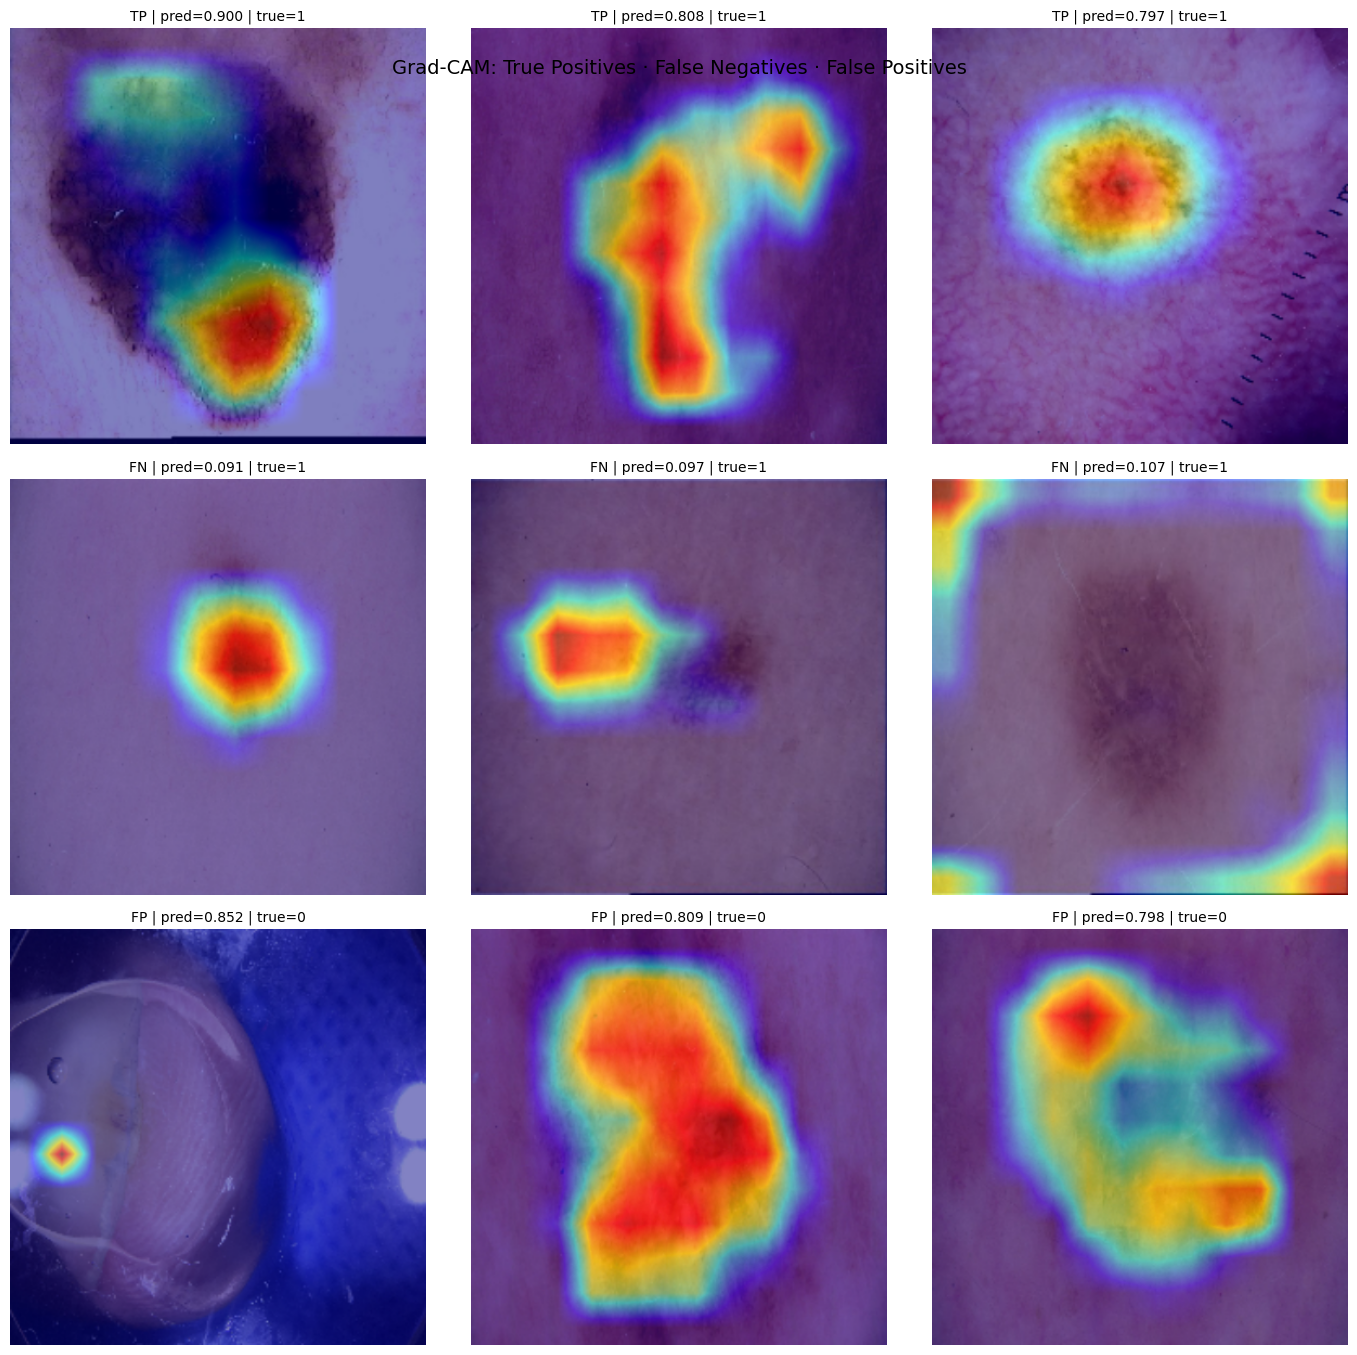

Saved to /teamspace/studios/this_studio/outputs/gradcam_analysis.png


In [14]:
# ── 1. Grad-CAM Visualisation ─────────────────────────────────────────────────
# Shows WHERE the model looks for melanoma vs benign decisions.
# Requires: pip install grad-cam

import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


class ModelWrapper(torch.nn.Module):
    """Wraps MelanomaModel so Grad-CAM sees a single-input CNN.
    Metadata is frozen to the provided vector."""
    def __init__(self, model, meta_tensor):
        super().__init__()
        self.model = model
        self.meta = meta_tensor  # (1, n_meta) on correct device

    def forward(self, x):
        B = x.shape[0]
        meta = self.meta.expand(B, -1)
        return self.model(x, meta).unsqueeze(-1)  # (B,1) for GradCAM


def load_image_for_gradcam(image_name, cfg):
    """Returns (rgb_float 0-1 for overlay, tensor for model)."""
    path = f"{cfg.img_dir}/{image_name}{cfg.img_ext}"
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    tfm = A.Compose([
        A.Resize(cfg.img_size, cfg.img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])
    tensor = tfm(image=img_rgb)["image"].unsqueeze(0)  # (1,3,H,W)

    # For overlay: resize to same dims, scale 0-1
    rgb_small = cv2.resize(img_rgb, (cfg.img_size, cfg.img_size))
    rgb_float = rgb_small.astype(np.float32) / 255.0
    return rgb_float, tensor


# ── Load OOF and pick interesting cases ────────────────────────────────────────
oof = pd.read_csv(f"{CFG.output_dir}/oof_predictions.csv")

tp = oof[(oof.target == 1) & (oof.pred >= 0.30)].nlargest(3, "pred")   # confident TP
fn = oof[(oof.target == 1) & (oof.pred < 0.30)].nsmallest(3, "pred")   # worst FN
fp = oof[(oof.target == 0) & (oof.pred >= 0.30)].nlargest(3, "pred")   # confident FP
cases = pd.concat([tp, fn, fp])
case_labels = ["TP"] * len(tp) + ["FN"] * len(fn) + ["FP"] * len(fp)

# ── Load fold-0 model ──────────────────────────────────────────────────────────
model = MelanomaModel(n_meta_features=len(meta_cols), cfg=CFG).to(CFG.device)
ckpt = torch.load(f"{CFG.output_dir}/fold0_best.pth", map_location=CFG.device)
model.load_state_dict(ckpt)
model.eval()

# Target layer: last block of the EfficientNet backbone
target_layer = model.backbone.blocks[-1]

# Dummy metadata (zeros) — keeps Grad-CAM focused on image features
dummy_meta = torch.zeros(1, len(meta_cols), device=CFG.device)
wrapper = ModelWrapper(model, dummy_meta)

cam = GradCAM(model=wrapper, target_layers=[target_layer])

# ── Plot ────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle("Grad-CAM: True Positives · False Negatives · False Positives", fontsize=14, y=0.93)

for idx, (_, row) in enumerate(cases.iterrows()):
    rgb_float, tensor = load_image_for_gradcam(row.image_name, CFG)
    tensor_dev = tensor.to(CFG.device)

    grayscale_cam = cam(input_tensor=tensor_dev, targets=None)[0]  # (H, W)
    overlay = show_cam_on_image(rgb_float, grayscale_cam, use_rgb=True)

    ax = axes[idx // 3, idx % 3]
    ax.imshow(overlay)
    label = case_labels[idx]
    ax.set_title(f"{label} | pred={row.pred:.3f} | true={int(row.target)}", fontsize=10)
    ax.axis("off")

for r, label in enumerate(["True Positive", "False Negative", "False Positive"]):
    axes[r, 0].set_ylabel(label, fontsize=12, rotation=90, labelpad=15)

plt.tight_layout()
plt.savefig(f"{CFG.output_dir}/gradcam_analysis.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved to {CFG.output_dir}/gradcam_analysis.png")

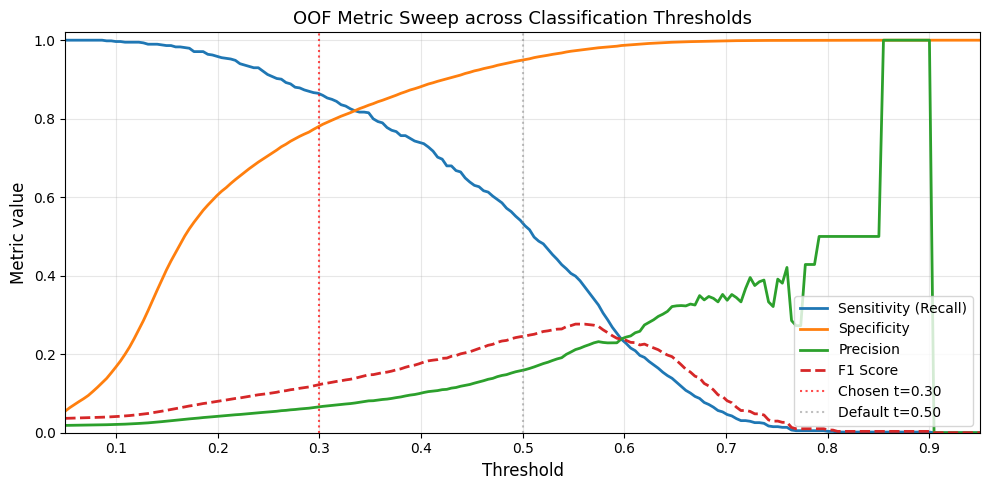

t=0.20 → Sens=0.959  Spec=0.604  Prec=0.042  F1=0.080
t=0.30 → Sens=0.865  Spec=0.779  Prec=0.066  F1=0.122
t=0.40 → Sens=0.740  Spec=0.880  Prec=0.100  F1=0.176
t=0.50 → Sens=0.541  Spec=0.948  Prec=0.158  F1=0.245


In [15]:
# ── 2. Threshold Sweep ────────────────────────────────────────────────────────
# Justifies the choice of t=0.30 by showing all metrics as a function of threshold.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

oof = pd.read_csv(f"{CFG.output_dir}/oof_predictions.csv")
labels = oof["target"].values
preds  = oof["pred"].values

thresholds = np.linspace(0.05, 0.95, 200)
results = []

for t in thresholds:
    y_hat = (preds >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, y_hat, labels=[0, 1]).ravel()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)
    prec = tp / (tp + fp + 1e-8)
    f1   = 2 * prec * sens / (prec + sens + 1e-8)
    results.append(dict(threshold=t, sensitivity=sens, specificity=spec, precision=prec, f1=f1))

res = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res.threshold, res.sensitivity, label="Sensitivity (Recall)", linewidth=2)
ax.plot(res.threshold, res.specificity, label="Specificity", linewidth=2)
ax.plot(res.threshold, res.precision,   label="Precision", linewidth=2)
ax.plot(res.threshold, res.f1,          label="F1 Score", linewidth=2, linestyle="--")

ax.axvline(0.30, color="red", linestyle=":", alpha=0.7, label="Chosen t=0.30")
ax.axvline(0.50, color="gray", linestyle=":", alpha=0.5, label="Default t=0.50")

ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Metric value", fontsize=12)
ax.set_title("OOF Metric Sweep across Classification Thresholds", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0.05, 0.95)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG.output_dir}/threshold_sweep.png", dpi=200, bbox_inches="tight")
plt.show()

# Print metrics at key thresholds
for t_val in [0.20, 0.30, 0.40, 0.50]:
    row = res.iloc[(res.threshold - t_val).abs().idxmin()]
    print(f"t={t_val:.2f} → Sens={row.sensitivity:.3f}  Spec={row.specificity:.3f}  "
          f"Prec={row.precision:.3f}  F1={row.f1:.3f}")

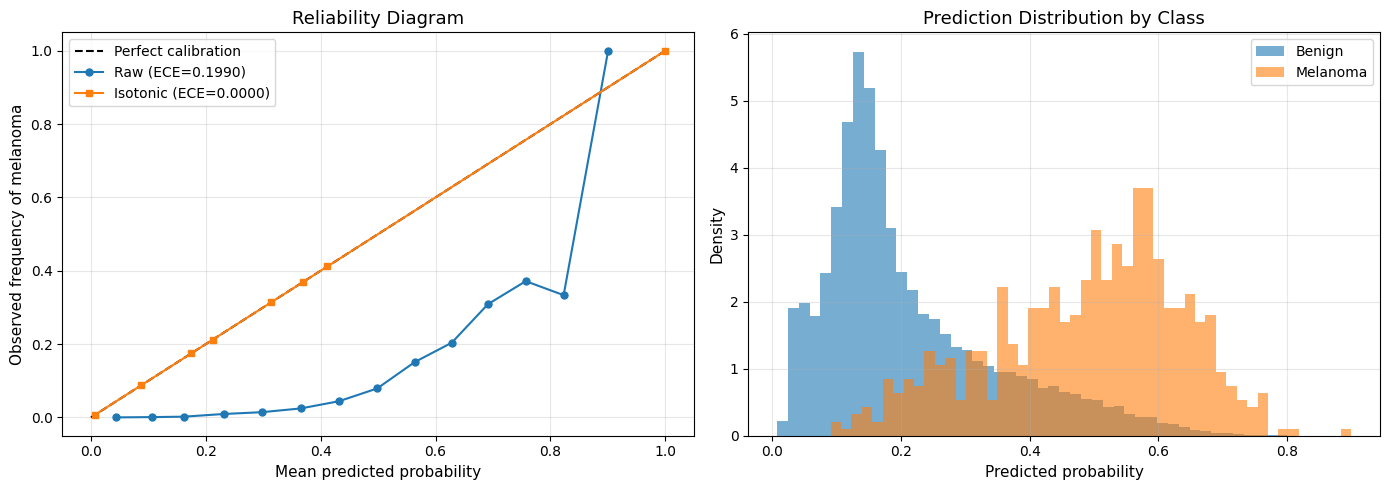

Raw   → Brier: 0.06734  ECE: 0.19905
Isot. → Brier: 0.01548  ECE: 0.00000

Note: isotonic is fit on the same OOF data (optimistic estimate).
For a proper evaluation, use nested CV or a held-out calibration set.


In [16]:
# ── 3. Calibration Analysis ───────────────────────────────────────────────────
# Reliability diagram + ECE + Brier score. Shows whether predicted probabilities
# match observed melanoma frequencies.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

oof = pd.read_csv(f"{CFG.output_dir}/oof_predictions.csv")
labels = oof["target"].values.astype(int)
preds  = oof["pred"].values


def expected_calibration_error(y_true, y_prob, n_bins=15):
    """Computes ECE: weighted average of |accuracy - confidence| per bin."""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        bin_acc  = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        ece += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(y_true)


# ── Before calibration ─────────────────────────────────────────────────────────
brier_raw = brier_score_loss(labels, preds)
ece_raw   = expected_calibration_error(labels, preds)
frac_pos_raw, mean_pred_raw = calibration_curve(labels, preds, n_bins=15, strategy="uniform")

# ── Isotonic calibration (fit on OOF — ideally use a held-out set) ─────────────
iso = IsotonicRegression(out_of_bounds="clip")
preds_cal = iso.fit_transform(preds, labels)

brier_cal = brier_score_loss(labels, preds_cal)
ece_cal   = expected_calibration_error(labels, preds_cal)
frac_pos_cal, mean_pred_cal = calibration_curve(labels, preds_cal, n_bins=15, strategy="uniform")

# ── Plot ────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: reliability diagram
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.plot(mean_pred_raw, frac_pos_raw, "o-", label=f"Raw (ECE={ece_raw:.4f})", markersize=5)
ax.plot(mean_pred_cal, frac_pos_cal, "s-", label=f"Isotonic (ECE={ece_cal:.4f})", markersize=5)
ax.set_xlabel("Mean predicted probability", fontsize=11)
ax.set_ylabel("Observed frequency of melanoma", fontsize=11)
ax.set_title("Reliability Diagram", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right: histogram of predicted probabilities
ax = axes[1]
ax.hist(preds[labels == 0], bins=50, alpha=0.6, label="Benign", density=True)
ax.hist(preds[labels == 1], bins=50, alpha=0.6, label="Melanoma", density=True)
ax.set_xlabel("Predicted probability", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Prediction Distribution by Class", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CFG.output_dir}/calibration_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Raw   → Brier: {brier_raw:.5f}  ECE: {ece_raw:.5f}")
print(f"Isot. → Brier: {brier_cal:.5f}  ECE: {ece_cal:.5f}")
print(f"\nNote: isotonic is fit on the same OOF data (optimistic estimate).")
print(f"For a proper evaluation, use nested CV or a held-out calibration set.")

Melanomas: 584 total — 505 TP, 79 FN at t=0.3


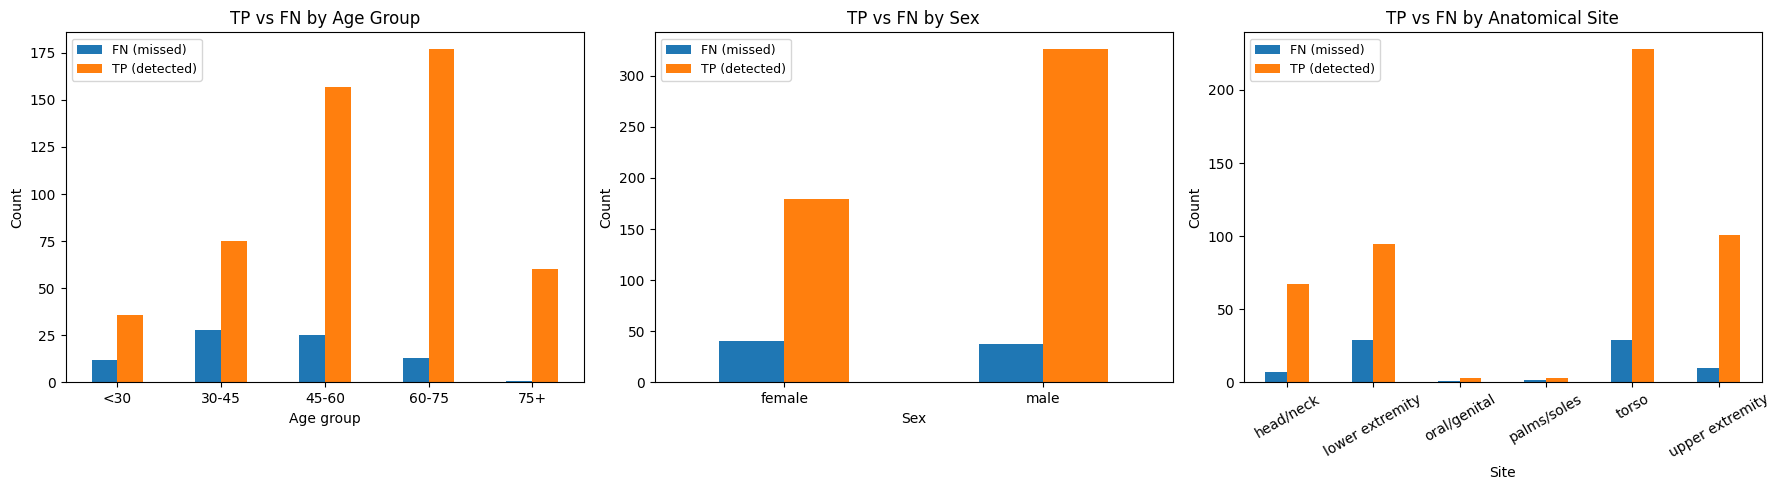


Miss rate (FN / total melanomas) by subgroup:
--------------------------------------------------

Age:
  <30                             12/48 missed (25.0%)
  30-45                           28/103 missed (27.2%)
  45-60                           25/182 missed (13.7%)
  60-75                           13/190 missed (6.8%)
  75+                             1/61 missed (1.6%)

Sex:
  female                          41/220 missed (18.6%)
  male                            38/364 missed (10.4%)

Site:
  head/neck                       7/74 missed (9.5%)
  lower extremity                 29/124 missed (23.4%)
  oral/genital                    1/4 missed (25.0%)
  palms/soles                     2/5 missed (40.0%)
  torso                           29/257 missed (11.3%)
  upper extremity                 10/111 missed (9.0%)


In [17]:
# ── 4. Error Analysis by Subgroup ─────────────────────────────────────────────
# Which melanomas does the model miss? Break down FN vs TP by age, sex, body site.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

oof = pd.read_csv(f"{CFG.output_dir}/oof_predictions.csv")
train_df = pd.read_csv(CFG.train_csv)

# Merge metadata onto OOF
merged = oof.merge(
    train_df[["image_name", "age_approx", "sex", "anatom_site_general_challenge"]],
    on="image_name", how="left"
)

THRESHOLD = 0.30
mel = merged[merged.target == 1].copy()
mel["outcome"] = np.where(mel.pred >= THRESHOLD, "TP (detected)", "FN (missed)")

print(f"Melanomas: {len(mel)} total — {(mel.outcome=='TP (detected)').sum()} TP, "
      f"{(mel.outcome=='FN (missed)').sum()} FN at t={THRESHOLD}")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Age distribution ───────────────────────────────────────────────────────────
ax = axes[0]
mel["age_bin"] = pd.cut(mel["age_approx"], bins=[0, 30, 45, 60, 75, 100],
                        labels=["<30", "30-45", "45-60", "60-75", "75+"])
age_ct = mel.groupby(["age_bin", "outcome"], observed=True).size().unstack(fill_value=0)
age_ct.plot(kind="bar", ax=ax, rot=0)
ax.set_title("TP vs FN by Age Group", fontsize=12)
ax.set_xlabel("Age group")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

# ── Sex ─────────────────────────────────────────────────────────────────────────
ax = axes[1]
sex_ct = mel.groupby(["sex", "outcome"], observed=True).size().unstack(fill_value=0)
sex_ct.plot(kind="bar", ax=ax, rot=0)
ax.set_title("TP vs FN by Sex", fontsize=12)
ax.set_xlabel("Sex")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

# ── Anatomical site ────────────────────────────────────────────────────────────
ax = axes[2]
site_ct = mel.groupby(["anatom_site_general_challenge", "outcome"], observed=True).size().unstack(fill_value=0)
site_ct.plot(kind="bar", ax=ax, rot=30)
ax.set_title("TP vs FN by Anatomical Site", fontsize=12)
ax.set_xlabel("Site")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{CFG.output_dir}/error_subgroup_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

# ── Miss rates per subgroup ────────────────────────────────────────────────────
print("\nMiss rate (FN / total melanomas) by subgroup:")
print("-" * 50)
for col, name in [("age_bin", "Age"), ("sex", "Sex"),
                   ("anatom_site_general_challenge", "Site")]:
    grouped = mel.groupby(col, observed=True).agg(
        total=("target", "count"),
        missed=("outcome", lambda x: (x == "FN (missed)").sum())
    )
    grouped["miss_rate"] = (grouped.missed / grouped.total * 100).round(1)
    print(f"\n{name}:")
    for idx, row in grouped.iterrows():
        print(f"  {str(idx):30s}  {row.missed:.0f}/{row.total:.0f} missed ({row.miss_rate}%)")

Loaded 39 rows from /teamspace/studios/this_studio/outputs/epoch_logs.csv


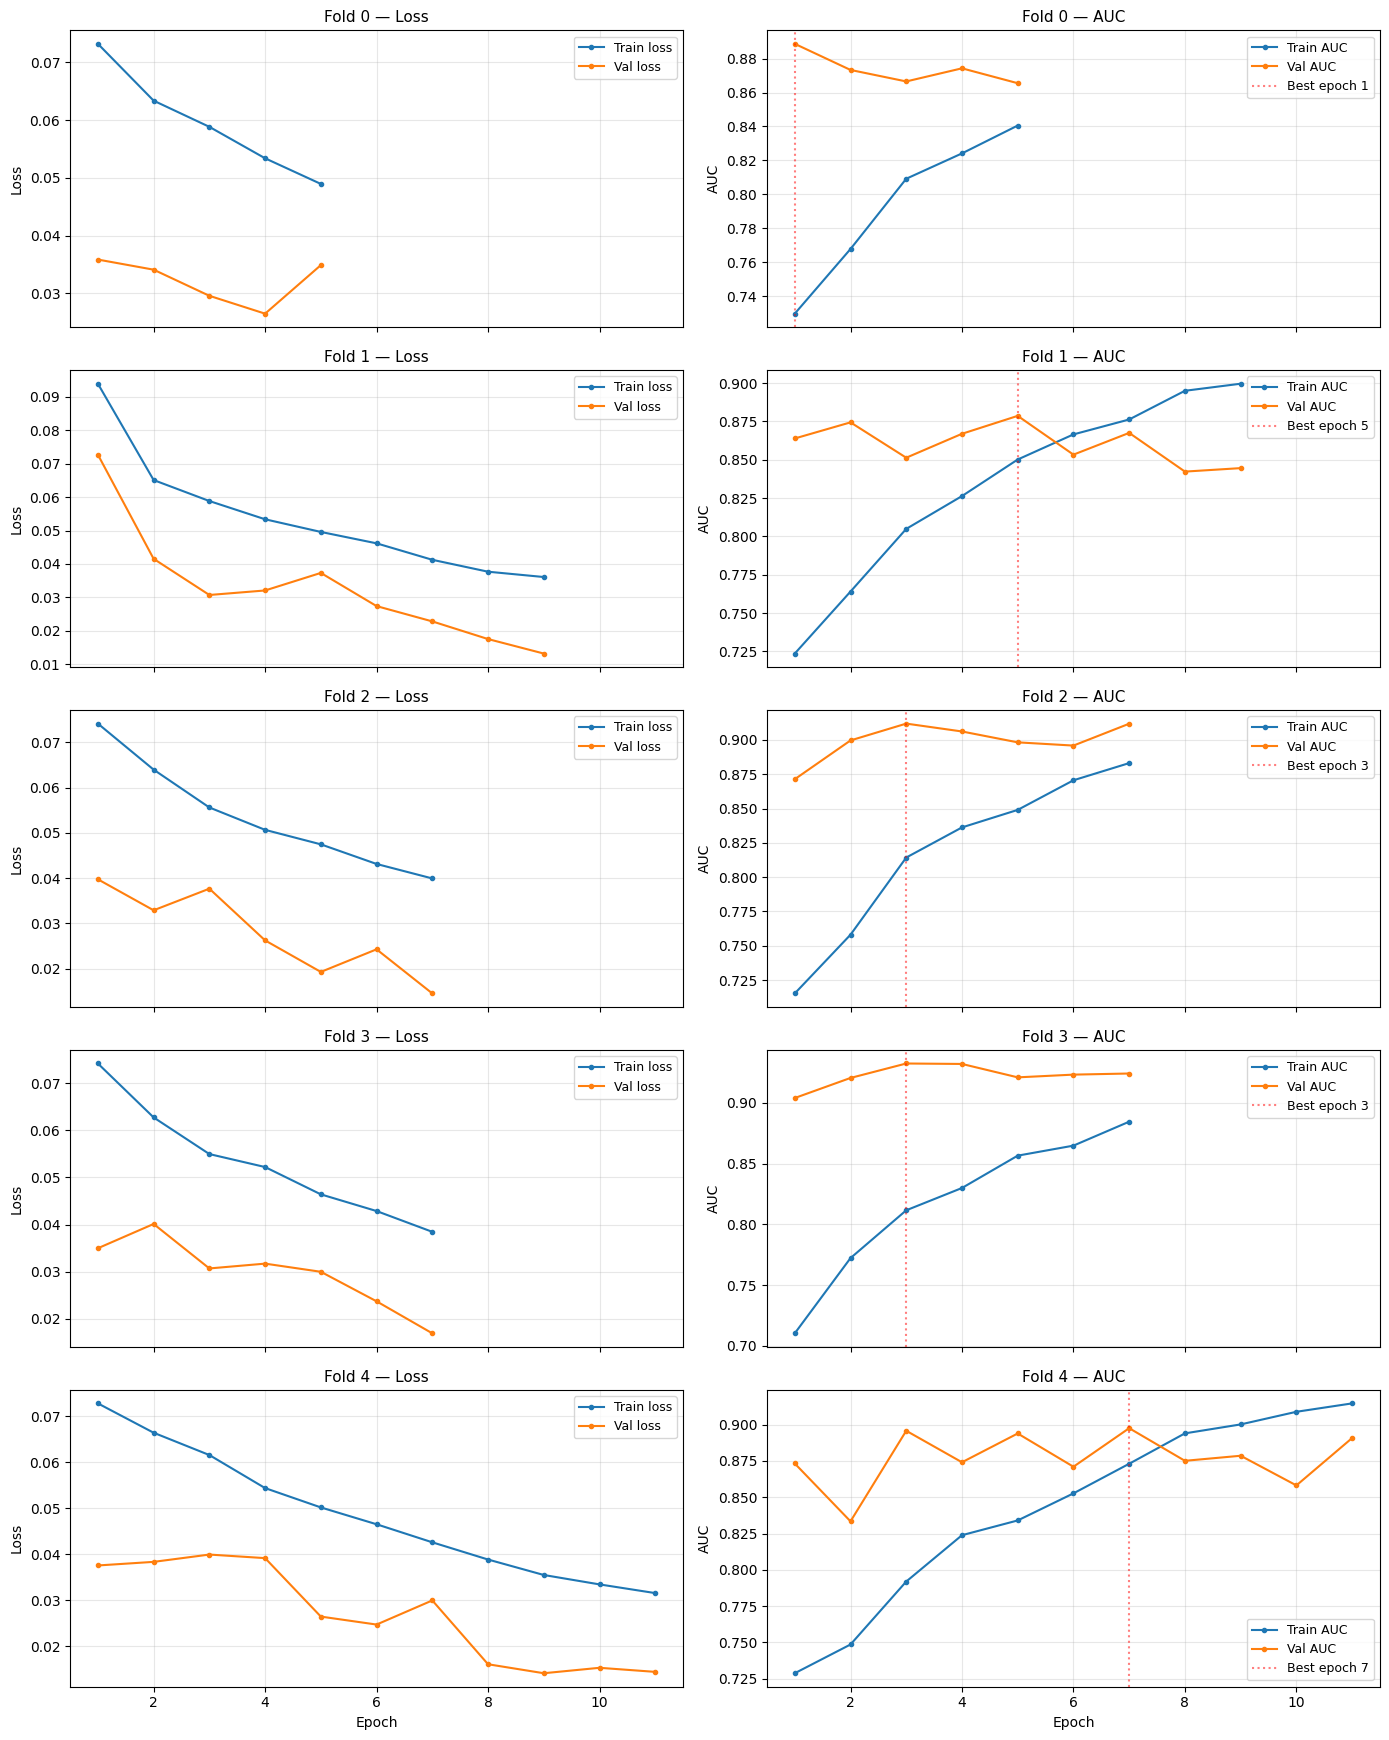

In [3]:
# ── 5. Learning Curves ────────────────────────────────────────────────────────
# Plots train vs val loss and AUC per epoch for each fold.
# REQUIREMENT: You need to log per-epoch metrics during run_kfold.
#
# Add this inside your run_kfold epoch loop (after train_one_epoch + validate):
#
#   epoch_logs.append({
#       "fold": fold, "epoch": epoch + 1,
#       "train_loss": train_loss, "train_auc": train_auc,
#       "val_loss": val_loss, "val_auc": val_auc,
#   })
#
# Then after the fold loop:
#   pd.DataFrame(epoch_logs).to_csv(f"{cfg.output_dir}/epoch_logs.csv", index=False)
#
# If you already have epoch_logs.csv, the cell below just plots it.
# If you DON'T have it yet, use the modified run_kfold_with_logging below.

import pandas as pd
import matplotlib.pyplot as plt

LOG_PATH = f"{CFG.output_dir}/epoch_logs.csv"

try:
    logs = pd.read_csv(LOG_PATH)
    print(f"Loaded {len(logs)} rows from {LOG_PATH}")
except FileNotFoundError:
    print(f"⚠ {LOG_PATH} not found.")
    print("Add epoch logging to run_kfold (see comments above) and re-train,")
    print("OR run the modified training cell below.")
    logs = None

if logs is not None:
    n_folds = logs["fold"].nunique()
    fig, axes = plt.subplots(n_folds, 2, figsize=(14, 3.5 * n_folds), sharex=True)
    if n_folds == 1:
        axes = axes[np.newaxis, :]  # ensure 2D

    for fold in sorted(logs["fold"].unique()):
        flog = logs[logs["fold"] == fold]

        # Loss
        ax = axes[fold, 0]
        ax.plot(flog.epoch, flog.train_loss, "o-", label="Train loss", markersize=3)
        ax.plot(flog.epoch, flog.val_loss, "o-", label="Val loss", markersize=3)
        ax.set_ylabel("Loss")
        ax.set_title(f"Fold {fold} — Loss", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

        # AUC
        ax = axes[fold, 1]
        ax.plot(flog.epoch, flog.train_auc, "o-", label="Train AUC", markersize=3)
        ax.plot(flog.epoch, flog.val_auc, "o-", label="Val AUC", markersize=3)
        best_row = flog.loc[flog.val_auc.idxmax()]
        ax.axvline(best_row.epoch, color="red", linestyle=":", alpha=0.5, label=f"Best epoch {int(best_row.epoch)}")
        ax.set_ylabel("AUC")
        ax.set_title(f"Fold {fold} — AUC", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    axes[-1, 0].set_xlabel("Epoch")
    axes[-1, 1].set_xlabel("Epoch")
    plt.tight_layout()
    plt.savefig(f"{CFG.output_dir}/learning_curves.png", dpi=200, bbox_inches="tight")
    plt.show()

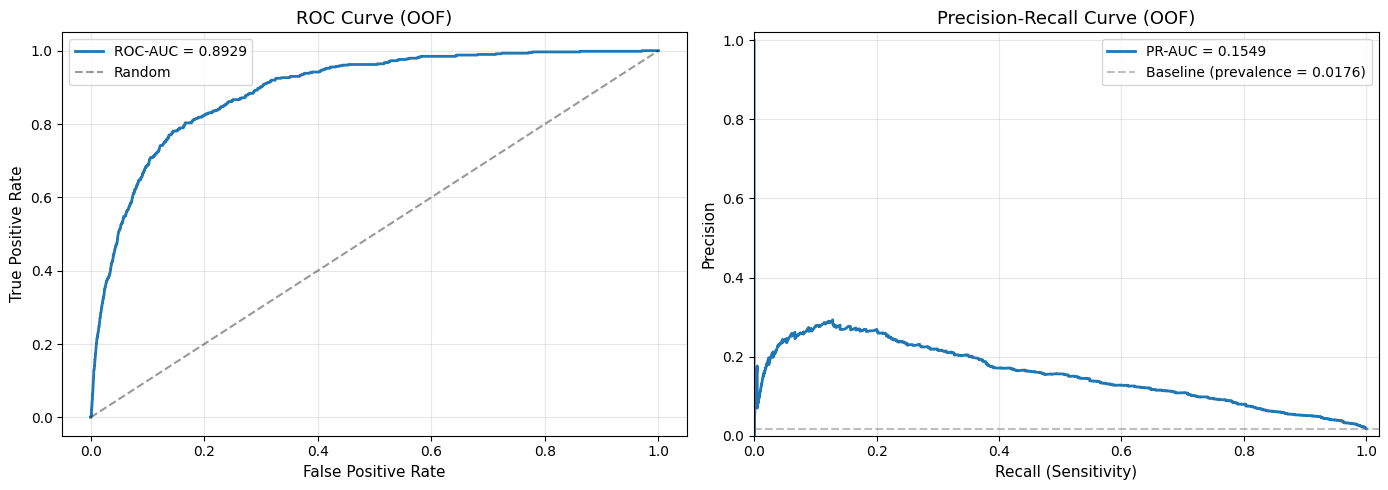

ROC-AUC: 0.8929
PR-AUC:  0.1549
Prevalence (baseline PR): 0.0176


In [22]:
# ── 6. PR Curve + ROC Curve side by side ──────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
)

oof = pd.read_csv(f"{CFG.output_dir}/oof_predictions.csv")
labels = oof["target"].values
preds  = oof["pred"].values

fpr, tpr, _ = roc_curve(labels, preds)
roc_auc = auc(fpr, tpr)

prec, rec, _ = precision_recall_curve(labels, preds)
pr_auc = average_precision_score(labels, preds)

prevalence = labels.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
ax = axes[0]
ax.plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve (OOF)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# PR
ax = axes[1]
ax.plot(rec, prec, linewidth=2, label=f"PR-AUC = {pr_auc:.4f}")
ax.axhline(prevalence, color="gray", linestyle="--", alpha=0.5,
           label=f"Baseline (prevalence = {prevalence:.4f})")
ax.set_xlabel("Recall (Sensitivity)", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision-Recall Curve (OOF)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(f"{CFG.output_dir}/roc_pr_curves.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"Prevalence (baseline PR): {prevalence:.4f}")

Baseline fold-0 val AUC: 0.8888
  age_norm                             AUC=0.8844  drop=+0.0044
  sex_enc                              AUC=0.8877  drop=+0.0011
  n_images                             AUC=0.8771  drop=+0.0117
  image_size                           AUC=0.8742  drop=+0.0145
  site_head/neck                       AUC=0.8890  drop=-0.0003
  site_lower extremity                 AUC=0.8891  drop=-0.0003
  site_oral/genital                    AUC=0.8885  drop=+0.0002
  site_palms/soles                     AUC=0.8885  drop=+0.0002
  site_torso                           AUC=0.8874  drop=+0.0014
  site_upper extremity                 AUC=0.8889  drop=-0.0002
  site_nan                             AUC=0.8888  drop=-0.0000


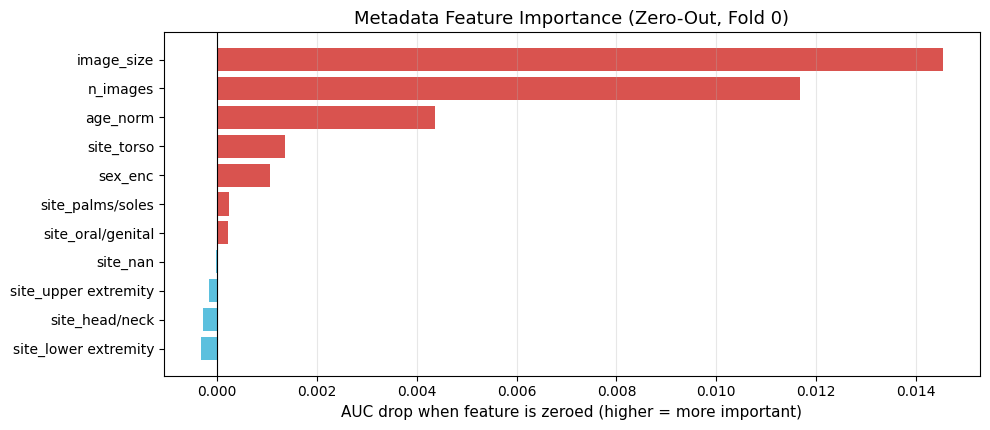

In [23]:
# ── 7. Metadata Feature Importance ────────────────────────────────────────────
# For each metadata feature, zero it out in the OOF metadata and measure AUC drop.
# Uses fold-0 model + fold-0 val set for speed.

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from torch.amp import autocast


def predict_val_fold0(model, val_loader, cfg):
    """Returns (labels, preds) for the val set."""
    model.eval()
    all_labels, all_preds = [], []
    device_type = "cuda" if str(cfg.device).startswith("cuda") else "cpu"
    with torch.no_grad():
        for images, meta, labels in val_loader:
            images = images.to(cfg.device, non_blocking=True)
            meta   = meta.to(cfg.device, non_blocking=True)
            with autocast(device_type=device_type, enabled=cfg.use_amp):
                logits = model(images, meta)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.append(probs)
            all_labels.append(labels.numpy())
    return np.concatenate(all_labels), np.concatenate(all_preds)


# ── Setup fold-0 ───────────────────────────────────────────────────────────────
model = MelanomaModel(n_meta_features=len(meta_cols), cfg=CFG).to(CFG.device)
ckpt = torch.load(f"{CFG.output_dir}/fold0_best.pth", map_location=CFG.device)
model.load_state_dict(ckpt)
model.eval()

train_tfm, val_tfm = get_transforms(CFG)
splits = make_splits(df, CFG)
_, val_loader = get_loaders(
    df=df, fold=0, meta_cols=meta_cols, cfg=CFG,
    train_tfm=train_tfm, val_tfm=val_tfm, splits=splits,
)

# ── Baseline AUC ───────────────────────────────────────────────────────────────
base_labels, base_preds = predict_val_fold0(model, val_loader, CFG)
base_auc = roc_auc_score(base_labels, base_preds)
print(f"Baseline fold-0 val AUC: {base_auc:.4f}")

# ── Zero-out each feature and measure AUC drop ─────────────────────────────────
importance = {}

for col_idx, col_name in enumerate(meta_cols):
    # Temporarily zero out column col_idx in the val dataset
    val_ds = val_loader.dataset
    original_vals = val_ds.df[col_name].values.copy()
    val_ds.df[col_name] = 0.0  # zero out

    _, preds_zeroed = predict_val_fold0(model, val_loader, CFG)
    auc_zeroed = roc_auc_score(base_labels, preds_zeroed)

    val_ds.df[col_name] = original_vals  # restore

    drop = base_auc - auc_zeroed
    importance[col_name] = drop
    print(f"  {col_name:35s}  AUC={auc_zeroed:.4f}  drop={drop:+.4f}")

# ── Plot ────────────────────────────────────────────────────────────────────────
imp_df = pd.DataFrame({
    "feature": list(importance.keys()),
    "auc_drop": list(importance.values()),
}).sort_values("auc_drop", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(imp_df) * 0.4)))
colors = ["#d9534f" if x > 0 else "#5bc0de" for x in imp_df.auc_drop]
ax.barh(imp_df.feature, imp_df.auc_drop, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("AUC drop when feature is zeroed (higher = more important)", fontsize=11)
ax.set_title("Metadata Feature Importance (Zero-Out, Fold 0)", fontsize=13)
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(f"{CFG.output_dir}/feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()